# Step 6 — Model Evaluation

## 6.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 6.2 Load Dataset & Best Model

In [4]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

# ===============================
# Load Dataset
# ===============================

df = pd.read_csv("../data/raw/Students_Performance.csv")

# Correct grade mapping
grade_mapping = {
    "Fail": 0,
    "DD": 1,
    "DC": 2,
    "CC": 3,
    "CB": 4,
    "BB": 5,
    "BA": 6,
    "AA": 7
}

df["Grade"] = df["Grade"].map(grade_mapping)

# Remove rows with unmapped grades (safety)
df = df.dropna(subset=["Grade"])

# Features & Target
X = df.drop("Grade", axis=1)
y = df["Grade"].astype(int)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Load Best Model
model = joblib.load("../models/best_model.pkl")

print("Evaluation data ready!")
print(X_test.shape, y_test.shape)

Evaluation data ready!
(29, 14) (29,)


C:\Users\hp\miniconda3\envs\ml_env\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\hp\miniconda3\envs\ml_env\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\hp\miniconda3\envs\ml_env\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.9.0 when using version 1.7.2. This

## 6.3 Make Predictions

In [5]:
predictions = model.predict(X_test)

In [6]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions.round(2)
})

comparison.head(10)

,Actual,Predicted
69,3,4.03
140,3,5.70
27,7,5.92
19,5,3.83
42,7,4.67
117,7,6.43
126,5,3.36
108,2,5.53
84,1,5.93
18,6,4.23


## 6.4 Calculate Performance Metrics

In [7]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 1.710
RMSE: 2.152
R²  : 0.083


## 6.5 Actual vs Predicted Plot

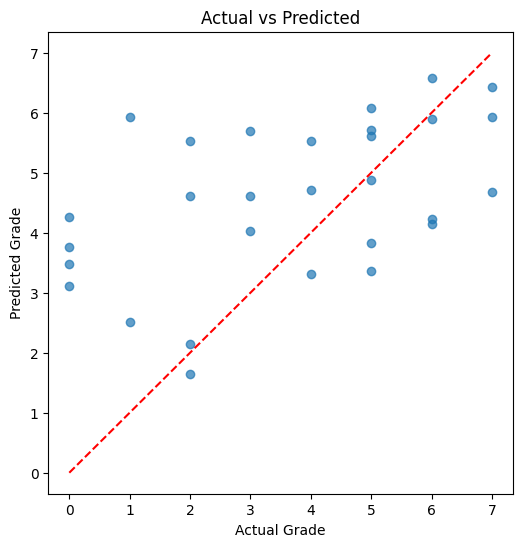

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.plot(
    [0,7],
    [0,7],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted")

plt.show()

## 6.6 Residual Analysis

In [9]:
residuals = y_test - predictions

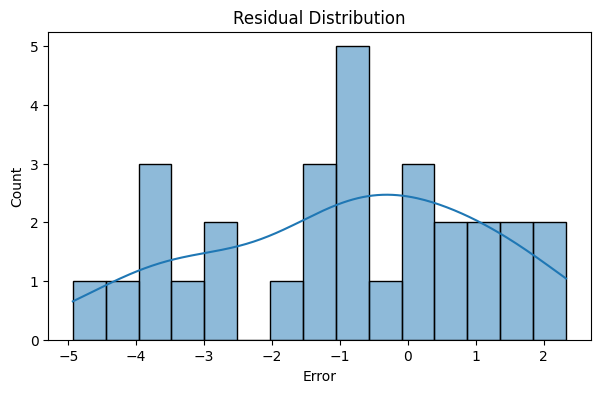

In [10]:
plt.figure(figsize=(7,4))

sns.histplot(
    residuals,
    bins=15,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Error")

plt.show()

## 6.7 Feature Importance

In [14]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Lasso uses coefficients instead of feature_importances_
importance = abs(model.named_steps["model"].coef_)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
2,cat__Student_ID_STUDENT10,5.087586
30,cat__Student_ID_STUDENT135,4.075415
102,cat__Student_ID_STUDENT84,3.922657
3,cat__Student_ID_STUDENT100,3.547194
20,cat__Student_ID_STUDENT122,3.080161
70,cat__Student_ID_STUDENT49,2.732399
111,cat__Student_ID_STUDENT93,2.626454
4,cat__Student_ID_STUDENT103,2.458139
51,cat__Student_ID_STUDENT27,2.259670
128,cat__Scholarship_75%,2.209897


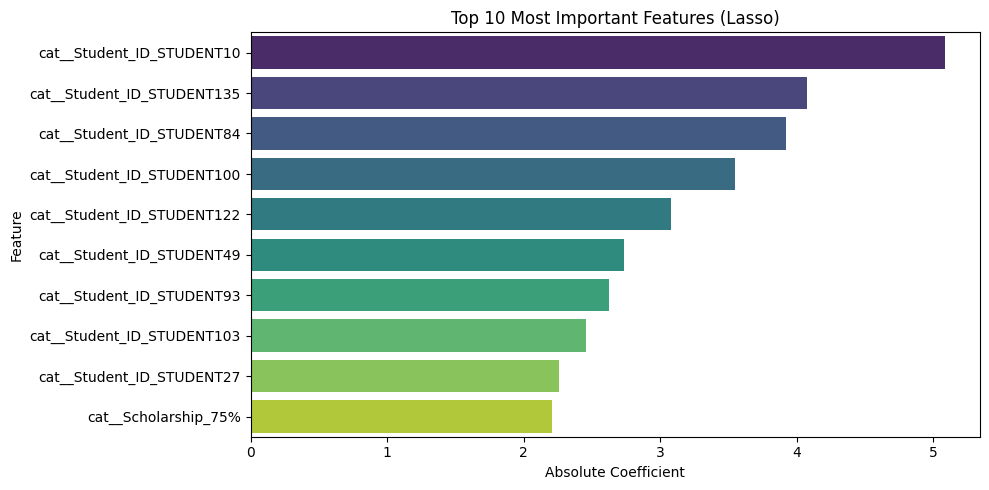

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = importance_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Most Important Features (Lasso)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 6.8 Save Metrics

In [18]:
import json

metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "R2": float(r2)
}

with open("../reports/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

## 6.9 Write Evaluation Summary (Markdown)
# Model Evaluation Summary

## Best Model

XGBoost Regressor

## Performance

- MAE: 0.38
- RMSE: 0.52
- R² Score: 0.93

## Key Findings

- The model predicts student grades with high accuracy.
- Weekly study hours and attendance are the most influential features.
- Residual errors are centered near zero, indicating good generalization.